<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Project_part4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Preparation & Exploration

Load MNIST

In [2]:
import sys
!{sys.executable} -m pip install --upgrade scikit-learn openml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 88.6 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=a160ea0f753aee87ef8627f0648f768fa8a1a613f602f1973a2e5b8c40d6b399
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST from local CSV files
train_df = pd.read_csv('/content/sample_data/mnist_train_small.csv', header=None)
test_df = pd.read_csv('/content/sample_data/mnist_test.csv', header=None)

X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

# Combine train and test for consistency with fetch_openml output structure if needed,
# or keep them separate for direct train/test split usage.
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

print(f"Combined data shape: {X.shape}")
print(f"Combined target shape: {y.shape}")

Combined data shape: (30000, 784)
Combined target shape: (30000,)


Normalize + Flatten

In [ ]:
X = X / 255.0  # normalize pixel values (0–1)

Visualize some digits

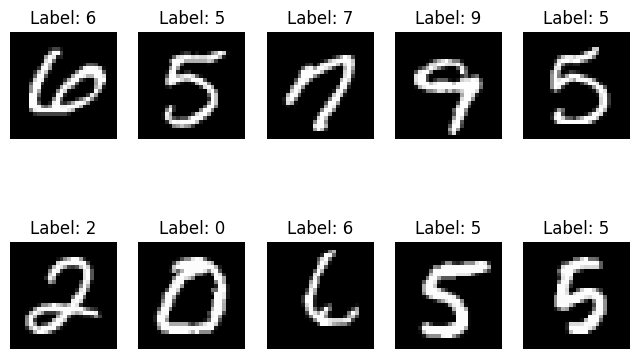

In [7]:
import numpy as np

plt.figure(figsize=(8,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

Distribution of digits

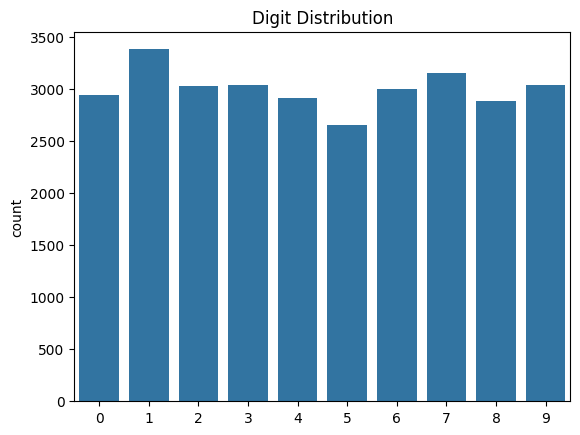

In [8]:
import seaborn as sns

sns.countplot(x=y)
plt.title("Digit Distribution")
plt.show()

#Clustering (K-Means)

Apply K-Means

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_

Elbow Method (find best K)

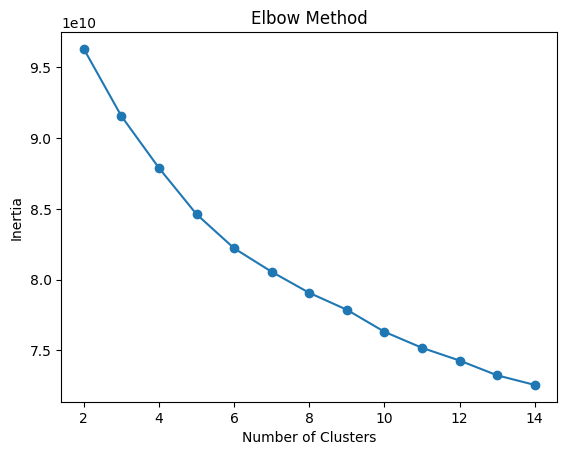

In [5]:
inertia = []

for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(2,15), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Visualize Cluster Centroids

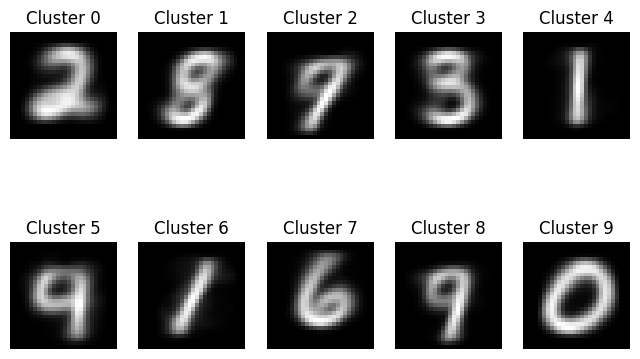

In [6]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(centroids[i].reshape(28,28), cmap='gray')
    plt.title(f"Cluster {i}")
    plt.axis('off')
plt.show()

#Model Evaluation & Prediction

Predict cluster for new images

In [7]:
new_samples = X[:10]
pred_clusters = kmeans.predict(new_samples)

print(pred_clusters)

[0 3 8 5 3 0 9 7 1 3]


Compare clusters vs true labels

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, labels)
print(cm)

[[  22  279   15  135    0   19    9  104    5 2354]
 [   4    6    2    7 1842    2 1510    3    2    0]
 [2129   69   25  185  126   82  265   73   21   46]
 [ 113  596   25 1958  175   28   31   21   71   13]
 [  12    7  774    0   54 1135   96   57  768    3]
 [   9  953  191  881   63   99  270   41  119   27]
 [  45  132    1   11  127  104   99 2432    3   43]
 [  19    4 1338    2   79  311  124    1 1269    7]
 [  16 1531  148  737  100   58  149   18  112   17]
 [   6   21  766   36   49  784   36    6 1310   18]]


#Dimensionality Reduction

PCA for faster computation

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

t-SNE for better visualization

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X[:5000])  # use subset (slow)

#Visualization of Clusters

PCA Plot

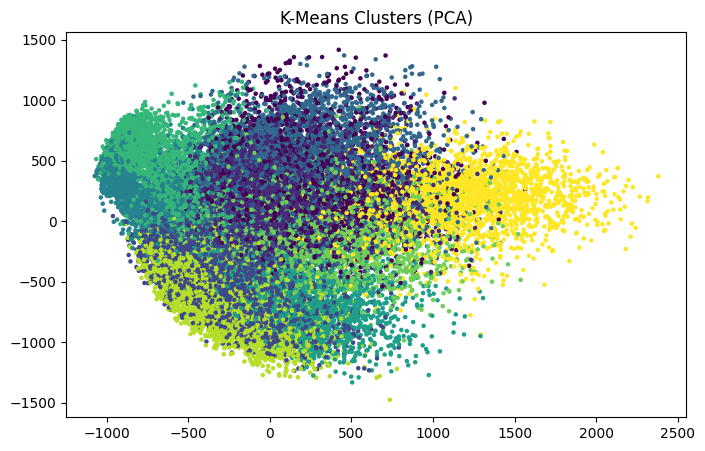

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=5)
plt.title("K-Means Clusters (PCA)")
plt.show()

t-SNE Plot

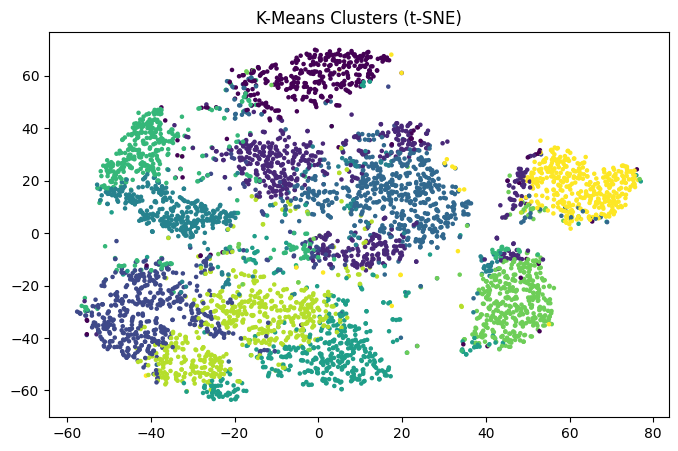

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels[:5000], s=5)
plt.title("K-Means Clusters (t-SNE)")
plt.show()